In [1]:
import os
import pandas as pd
import numpy as np
import datetime as dt
import math
from tqdm import tqdm

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2025-02-05 22:15:19.549293


#### Functions

In [3]:
def split_data(flt_prop_row):
    if flt_prop_row <= 0.60:
        return 'train'
    elif flt_prop_row <= 0.8:
        return 'test'
    else:
        return 'holdout'

#### Constants

In [4]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

# task
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

# subtask
str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

# get the dob
int_dob = int(str_task[3:].split('_')[-3])
print(f'DOB: {int_dob}')

# logic
if int_dob == 720:
    str_target = 'Early_Pay_Delinquency_60_720_Flag'
else:
    pass
print(f'Target: {str_target}')

str_dirname_output = './output'

flt_thresh_train = 0.60

flt_thresh_test = 0.80

Project: 20241112-simple-model-test
Task: 16_60_in_720_chargeoff_dl
Subtask: 01_data_split
DOB: 720
Target: Early_Pay_Delinquency_60_720_Flag


#### Make output directory

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [6]:
%%time

str_filename = 'df.gzip'
str_uri = f's3://{str_project}/08_prep_data/{str_filename}'
df = pd.read_parquet(
    str_uri,
)

# get month of request
df['request_month'] = df['request_datetime'].apply(
    lambda x: f'{str(x)[:7]}-01',
)
df['request_month'] = pd.to_datetime(df['request_month']).dt.date
# sort
df.sort_values(by='request_datetime', ascending=True, inplace=True)

# rm too new
df = df[df['request_datetime'] < '2022-12-01'].copy()

# show
df

CPU times: user 11.2 s, sys: 4.02 s, total: 15.2 s
Wall time: 6.12 s


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month
0,5702434,2021-07-26 16:29:29.3903686,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Iowa,Franchise,Iowa,True,...,0,7,NaN,1.311220,1,0,0,0,0.616667,2021-07-01
1,5714239,2021-07-26 16:39:34.1121025,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,0,5,NaN,1.432368,0,0,0,0,NaN,2021-07-01
2,5713063,2021-07-26 16:48:39.3211104,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,0,4,NaN,1.587073,1,0,0,0,NaN,2021-07-01
3,5713732,2021-07-27 09:02:35.3300974,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Michigan,Independent,Michigan,False,...,0,2,NaN,1.081881,0,1,0,1,0.000000,2021-07-01
4,5715634,2021-07-27 09:18:12.2190097,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,0,4,NaN,1.371350,0,1,0,1,0.000000,2021-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41693,6453589,2022-11-30 23:45:32+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,0,5,NaN,1.478650,0,0,0,1,0.000000,2022-11-01
41694,6418453,2022-11-30 23:48:36+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Independent,Michigan,False,...,0,9,NaN,1.090807,0,0,0,0,0.000000,2022-11-01
41695,6411914,2022-11-30 23:53:12+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Washington,Independent,Washington,True,...,0,6,NaN,1.352150,0,0,0,0,NaN,2022-11-01
41696,6434554,2022-11-30 23:57:04+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,0,4,NaN,1.024680,1,0,0,0,0.137374,2022-11-01


#### Create target

<Axes: ylabel='Frequency'>

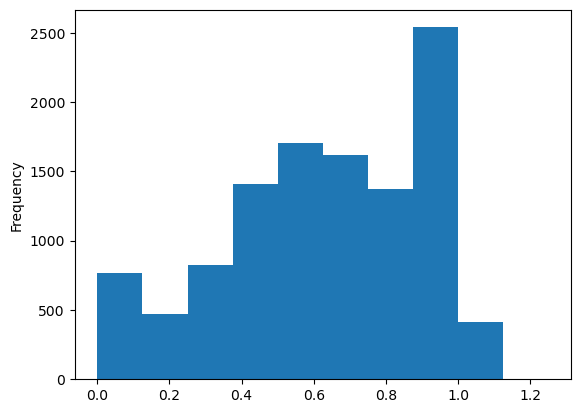

In [7]:
# get those that went delinquent
df = df[df[str_target] == 1].copy()
# clip
df[str_target] = df[f'loss_at_{int_dob}'].clip(lower=0)

# get those that had a positive net charge off
df = df[df[str_target] > 0].copy()

# control for amt financed
df[str_target] = df[str_target] / df['amtfinanced__app']
# show
df[str_target].plot(kind='hist')

#### Remove too new from days on books (funded date - run date)

In [8]:
%%time

df = df[df['days_on_books'] >= int_dob].copy()
# show
df

CPU times: user 171 ms, sys: 168 ms, total: 338 ms
Wall time: 337 ms


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month
1,5714239,2021-07-26 16:39:34.1121025,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,0,5,NaN,1.432368,0,0,0,0,NaN,2021-07-01
12,5710164,2021-07-27 10:14:00.4561057,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Ohio,Independent,Ohio,False,...,1,7,NaN,1.087884,0,0,0,0,NaN,2021-07-01
11,5710164,2021-07-27 10:14:00.4561057,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Ohio,Independent,Ohio,False,...,1,7,NaN,1.087884,0,0,0,0,NaN,2021-07-01
31,5717801,2021-07-27 14:41:34.4547019,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Georgia,Franchise,Georgia,True,...,0,0,NaN,1.433137,0,0,0,0,0.000000,2021-07-01
45,5716285,2021-07-28 09:20:16.4034386,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,0,0,NaN,1.222982,0,0,0,0,0.000000,2021-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41673,6411478,2022-11-30 06:10:33+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-29.gzip,1,1,North Carolina,Independent,North Carolina,False,...,0,3,NaN,1.100414,0,0,0,0,NaN,2022-11-01
41676,6436364,2022-11-30 07:11:46+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Georgia,Franchise,Georgia,False,...,0,3,NaN,1.530976,0,0,0,0,NaN,2022-11-01
41684,6458979,2022-11-30 22:58:05+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Pennsylvania,Independent,Pennsylvania,True,...,0,2,0.071136,1.405987,0,1,1,0,0.000000,2022-11-01
41692,6450520,2022-11-30 23:33:56+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Illinois,Franchise,Wisconsin,True,...,0,-1,NaN,1.246665,1,0,0,0,0.416667,2022-11-01


#### Rm december

In [9]:
df = df[df['request_month'].astype(str) != '2022-12-01'].copy()

#### Split

In [10]:
df['row'] = range(1, df.shape[0] + 1)
df['prop_row'] = df['row'] / df.shape[0]

# split
df['data_set'] = df['prop_row'].apply(
    lambda x: split_data(x),
)
# show
df

,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month,row,prop_row,data_set
1,5714239,2021-07-26 16:39:34.1121025,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,1.432368,0,0,0,0,NaN,2021-07-01,1,0.00009,train
12,5710164,2021-07-27 10:14:00.4561057,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Ohio,Independent,Ohio,False,...,1.087884,0,0,0,0,NaN,2021-07-01,2,0.00018,train
11,5710164,2021-07-27 10:14:00.4561057,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Ohio,Independent,Ohio,False,...,1.087884,0,0,0,0,NaN,2021-07-01,3,0.00027,train
31,5717801,2021-07-27 14:41:34.4547019,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Georgia,Franchise,Georgia,True,...,1.433137,0,0,0,0,0.000000,2021-07-01,4,0.00036,train
45,5716285,2021-07-28 09:20:16.4034386,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,1.222982,0,0,0,0,0.000000,2021-07-01,5,0.00045,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41673,6411478,2022-11-30 06:10:33+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-29.gzip,1,1,North Carolina,Independent,North Carolina,False,...,1.100414,0,0,0,0,NaN,2022-11-01,11115,0.99964,holdout
41676,6436364,2022-11-30 07:11:46+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Georgia,Franchise,Georgia,False,...,1.530976,0,0,0,0,NaN,2022-11-01,11116,0.99973,holdout
41684,6458979,2022-11-30 22:58:05+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Pennsylvania,Independent,Pennsylvania,True,...,1.405987,0,1,1,0,0.000000,2022-11-01,11117,0.99982,holdout
41692,6450520,2022-11-30 23:33:56+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Illinois,Franchise,Wisconsin,True,...,1.246665,1,0,0,0,0.416667,2022-11-01,11118,0.99991,holdout


#### Create tags

In [11]:
%%time

# train
df['train'] = df['data_set'].apply(
    lambda x: 1 if x == 'train' else 0,
)

CPU times: user 4.51 ms, sys: 180 μs, total: 4.69 ms
Wall time: 4.3 ms


In [12]:
%%time

# test
df['test'] = df['data_set'].apply(
    lambda x: 1 if x == 'test' else 0,
)

CPU times: user 4.12 ms, sys: 43 μs, total: 4.17 ms
Wall time: 4 ms


In [13]:
%%time

# holdout
df['holdout'] = df['data_set'].apply(
    lambda x: 1 if x == 'holdout' else 0,
)

CPU times: user 4.08 ms, sys: 27 μs, total: 4.1 ms
Wall time: 3.96 ms


#### Write to s3

In [14]:
list_str_filename = [
    'train',
    'test',
    'holdout',
]
for str_filename in tqdm(list_str_filename):
    print(f'Filename: {str_filename}')
    # subset
    df_tmp = df[df[str_filename] == 1].copy()
    # get n rows
    int_nrows = df_tmp.shape[0]
    print(f'Rows: {int_nrows}')
    print()
    # make column name
    df_tmp['data_set'] = str_filename
    # write
    str_filename_tmp = f'df_{str_filename}.gzip'
    str_uri = f's3://{str_project}/{str_task}/{str_subtask}/{str_filename_tmp}'
    df_tmp.to_parquet(str_uri, compression='gzip')

  0%|          | 0/3 [00:00<?, ?it/s]

Filename: train
Rows: 6671



 33%|███▎      | 1/3 [00:03<00:06,  3.32s/it]

Filename: test
Rows: 2224



 67%|██████▋   | 2/3 [00:04<00:02,  2.29s/it]

Filename: holdout
Rows: 2224



100%|██████████| 3/3 [00:06<00:00,  2.12s/it]
